<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/projeto_xGMobile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from abc import ABC, abstractmethod
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [17]:
class LinearRegression:
    def __init__(self):
        self.x = None
        self.y = None
        self.__correlation_coefficient = None
        self.__inclination = None
        self.__intercept = None

    def __correlacao(self):
        covariacao = np.cov(self.x, self.y, bias=True)[0][1]
        variancia_x = np.var(self.x)
        variancia_y = np.var(self.y)

        return covariacao / np.sqrt(variancia_x * variancia_y)

    def __inclinacao(self):
        stdx = np.std(self.x)
        stdy = np.std(self.y)

        return self.__correlation_coefficient * (stdy / stdx)

    def __interceptacao(self):
        mediax = np.mean(self.x)
        mediay = np.mean(self.y)

        return mediay - mediax * self.__inclination

    def fit(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)

        self.__correlation_coefficient = self.__correlacao()
        self.__inclination = self.__inclinacao()
        self.__intercept = self.__interceptacao()

    def transform(self, valor):
        valor = np.array(valor)
        return self.__intercept + (self.__inclination * valor)

In [5]:
dataset_ai_adoption = pd.read_csv('/content/ai-adoption-fortune500-synthetic-dataset-2020-2025.csv', sep=',')
dataset_ai_adoption

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
0,2020,Amazon,E-commerce,USA,Real,Enterprise,4.535464e+11,Yes,Autonomous Driving,30.33,77
1,2021,Amazon,E-commerce,USA,Real,Enterprise,4.878035e+11,Yes,Generative AI,19.09,81
2,2022,Amazon,E-commerce,USA,Real,Enterprise,2.182500e+11,Yes,Supply Chain Optimization,34.99,79
3,2023,Amazon,E-commerce,USA,Real,Enterprise,4.114132e+11,Yes,Chatbots,23.96,72
4,2024,Amazon,E-commerce,USA,Real,Enterprise,3.191970e+11,No,NaN,0.00,27
...,...,...,...,...,...,...,...,...,...,...,...
5995,2021,SyntheticCorp_0980,Telecom,Brazil,Synthetic,Enterprise,1.398673e+10,No,NaN,0.00,6
5996,2022,SyntheticCorp_0980,Finance,India,Synthetic,SME,2.847901e+07,Yes,Demand Forecasting,29.14,75
5997,2023,SyntheticCorp_0980,Technology,Canada,Synthetic,Enterprise,3.516618e+10,No,NaN,0.00,28
5998,2024,SyntheticCorp_0980,Logistics,UAE,Synthetic,Enterprise,2.835842e+10,Yes,Chatbots,38.37,41


In [25]:
def investment(x:float, y:float)->float:
  return x/(1 + y/100)

dataset_ai_adoption['Investment'] = dataset_ai_adoption.apply(lambda row: investment(row['Revenue_USD'], row['AI_ROI_Percent']), axis=1)
dataset_ai_adoption

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score,Investment
0,2020,Amazon,E-commerce,USA,Real,Enterprise,4.535464e+11,Yes,Autonomous Driving,30.33,77,3.479985e+11
1,2021,Amazon,E-commerce,USA,Real,Enterprise,4.878035e+11,Yes,Generative AI,19.09,81,4.096091e+11
2,2022,Amazon,E-commerce,USA,Real,Enterprise,2.182500e+11,Yes,Supply Chain Optimization,34.99,79,1.616787e+11
3,2023,Amazon,E-commerce,USA,Real,Enterprise,4.114132e+11,Yes,Chatbots,23.96,72,3.318919e+11
4,2024,Amazon,E-commerce,USA,Real,Enterprise,3.191970e+11,No,NaN,0.00,27,3.191970e+11
...,...,...,...,...,...,...,...,...,...,...,...,...
5995,2021,SyntheticCorp_0980,Telecom,Brazil,Synthetic,Enterprise,1.398673e+10,No,NaN,0.00,6,1.398673e+10
5996,2022,SyntheticCorp_0980,Finance,India,Synthetic,SME,2.847901e+07,Yes,Demand Forecasting,29.14,75,2.205282e+07
5997,2023,SyntheticCorp_0980,Technology,Canada,Synthetic,Enterprise,3.516618e+10,No,NaN,0.00,28,3.516618e+10
5998,2024,SyntheticCorp_0980,Logistics,UAE,Synthetic,Enterprise,2.835842e+10,Yes,Chatbots,38.37,41,2.049463e+10


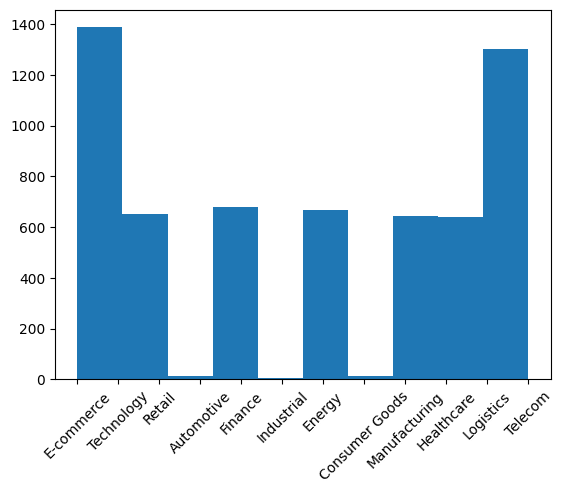

In [71]:
plt.hist(dataset_ai_adoption['Industry'])
plt.xticks(rotation=45)
plt.show()

In [76]:
dataset_ai_adoption = dataset_ai_adoption.drop(columns='Use_Case')
revenue = dataset_ai_adoption['Revenue_USD']
investment = dataset_ai_adoption['Investment']
dicio = {
    indu: {
        'Revenue': dataset_ai_adoption.loc[dataset_ai_adoption['Industry'] == indu, 'Revenue_USD'].tolist(),
        'Investment': dataset_ai_adoption.loc[dataset_ai_adoption['Industry'] == indu, 'Investment'].tolist(),
        'AI Maturity Score': dataset_ai_adoption.loc[dataset_ai_adoption['Industry'] == indu, 'AI_Maturity_Score'].tolist()
    }
    for indu in dataset_ai_adoption['Industry'].unique()
}
dicio.keys()


dict_keys(['E-commerce', 'Technology', 'Retail', 'Automotive', 'Finance', 'Industrial', 'Energy', 'Consumer Goods', 'Manufacturing', 'Healthcare', 'Logistics', 'Telecom'])

In [77]:
for indu, valores in dicio.items():
    print(f"Industry: {indu} - Revenue: {valores['Revenue']} - Investment: {valores['Investment']} - AI Maturity Score: {valores['AI Maturity Score']}\n")

Industry: E-commerce - Revenue: [453546411457.22, 487803518161.22, 218250038723.05, 411413209032.38, 319196981151.42, 201766884512.89, 454403195737.45, 368338455879.68, 194287658411.2, 276384388788.5, 192336758326.31, 305543258858.12, 11901130.23, 46459994327.57, 15863129214.81, 1840008892.28, 9945889822.13, 47757687532.09, 41021979283.15, 11636819398.68, 12548166619.55, 14089065.37, 29279929.11, 43668211.8, 7786363727.94, 4908096.02, 9957382.82, 24882681063.85, 21408153095.03, 4724026.25, 17046009085.35, 48587999.09, 42341528414.11, 30971077.0, 49718776707.14, 37994566.79, 12898108.8, 12237170.93, 16263594.38, 27501466.23, 24691554.07, 11135223.2, 34437387072.02, 15046815.84, 46274962230.65, 32154251483.11, 15075281453.34, 32652506180.41, 13017612582.66, 38747003028.49, 6240397824.32, 12518589781.13, 34844969269.52, 39061149.95, 1132367873.46, 5617141.49, 16287225.44, 38995582.15, 28736541465.04, 46838446.05, 9202305598.81, 13723604883.63, 13024373188.48, 13130430626.31, 48838285.22, 

In [78]:
df = pd.DataFrame(dicio)
df

,E-commerce,Technology,Retail,Automotive,Finance,Industrial,Energy,Consumer Goods,Manufacturing,Healthcare,Logistics,Telecom
Revenue,"[453546411457.22, 487803518161.22, 21825003872...","[79654626907.74, 334416638921.46, 407248269503...","[16783350450.9, 261119457913.56, 477358914802....","[230307288266.79, 439911775845.86, 21904181520...","[308770565040.04, 153806053366.98, 40479338546...","[468479344371.71, 435721334670.64, 11867737736...","[5310236387.31, 286311946547.74, 432633860578....","[325981234247.57, 270463770025.41, 36273017600...","[20809125.66, 32457836.16, 43282764.58, 275077...","[40263637159.19, 36709010405.61, 23398519801.8...","[10839131.73, 24517297.85, 16123067937.01, 181...","[19867387.2, 22435948.51, 22106641331.78, 2499..."
Investment,"[347998474224.8293, 409609134403.5771, 1616786...","[66623140605.336235, 239793947312.10382, 35742...","[14205120991.028353, 200367908159.57645, 35149...","[197012222640.5389, 381934168992.75916, 194617...","[237187405930.28113, 129761286903.72058, 28961...","[357372297178.8161, 324680577250.8495, 9377163...","[3805529874.8100905, 251084755369.4116, 342246...","[281333593033.201, 197231656111.28857, 3627301...","[15861823.050537387, 23846768.172801413, 32852...","[34984479241.62829, 28039268565.23831, 1999873...","[9590454.547867635, 18604718.356351495, 161230...","[19867387.2, 18952482.268964354, 18200758547.4..."
AI Maturity Score,"[77, 81, 79, 72, 27, 96, 71, 72, 84, 90, 82, 9...","[77, 96, 94, 87, 98, 89, 97, 91, 79, 83, 77, 9...","[86, 85, 82, 88, 37, 10, 60, 64, 65, 47, 50, 6...","[81, 84, 72, 96, 77, 76, 75, 94, 96, 81, 93, 76]","[93, 93, 82, 25, 20, 71, 73, 86, 75, 97, 89, 8...","[80, 90, 75, 95, 96, 99]","[85, 74, 96, 2, 80, 71, 96, 94, 82, 89, 99, 82...","[77, 94, 26, 83, 84, 85, 89, 70, 73, 100, 86, ...","[45, 76, 45, 42, 57, 72, 59, 62, 58, 47, 43, 5...","[83, 65, 79, 68, 29, 32, 5, 42, 78, 47, 85, 26...","[51, 69, 7, 49, 77, 53, 46, 81, 9, 73, 72, 44,...","[31, 59, 62, 56, 45, 78, 60, 83, 78, 77, 61, 4..."


In [6]:
dataset_global_ai = pd.read_csv('/content/global_ai_tools_dataset_final.csv', sep=',')
dataset_global_ai

,tool_name,category,release_year,pricing,open_source,github_stars,company,monthly_users,tags
0,ChatGPT,LLM,2022,Freemium,No,180000,OpenAI,180000000,"chatbot,text,assistant"
1,Midjourney,Image Generation,2022,Paid,No,0,Independent,20000000,"image,design,art"
2,Claude,LLM,2023,Freemium,No,0,Anthropic,15000000,"chatbot,text,assistant"
3,Gemini,LLM,2024,Freemium,No,0,Google,120000000,"chatbot,text,search"
4,Stable Diffusion,Image Generation,2022,Free,Yes,150000,Stability AI,10000000,"image,generation,design"
...,...,...,...,...,...,...,...,...,...
3005,AITool_2996,LLM,2026,Free,Yes,33194,Adobe,10323097,"developer,image,text"
3006,AITool_2997,Music AI,2022,Freemium,No,107478,Google,41997303,"assistant,productivity,design"
3007,AITool_2998,Coding Assistant,2024,Freemium,No,51686,Startup,7605648,"text,assistant,automation"
3008,AITool_2999,Video AI,2024,Enterprise,Yes,48804,OpenAI,30491141,"voice,developer,productivity"
